# Pilot Analysis — LoRA Gemma-2-9B parsing self-repair SBN

**Model:** `Shrikes/sbn-gemma2-9b-lora-pmb` (LoRA on PMB 5.1.0 gold) -- v2, the `end_of_turn` mark is in the correct place.  
**Data:** `Shrikes/self_repair_parsing_pilot_data` (836 gold sentences × 7 conditions) -- all multi-sentence samples are removed.  
**Scoring:** smatch++ (flipz357/smatchpp), via `evaluate_smatchpp.py` -- being consistent with the latest PMB study by Bos team.

Each of the 836 source sentences is parsed under 7 conditions and scored against the **same** gold SBN (`mr`):

| group | conditions |
|---|---|
| baseline | `gold` |
| repair (plain) | `repair_head`, `repair_mid`, `repair_tail` |
| repair (+interregnum "I mean") | `repair_head_interrug`, `repair_mid_interrug`, `repair_tail_interrug` |

`gold` measures base parser quality; the repair conditions measure degradation when an un-trained-for self-repair is forced through the parser.

### Status codes
`success` = both gold & pred SBN → Penman → smatch++ OK.  `ill_formed` = pred rejected by strict mode (impossible indices).  `parse_error` = pred not parseable -- see Block 5 for more info.  `gold_error` = gold itself failed (should be ~0).  
`smatch_error` = scoring crashed.

### Two F1 metrics
* **F1 (A, success-only):** mean over rows where `status == success`. Hides failure cost.
* **F1 (B, penalized):** failures counted as F1 = 0, mean over **all** rows. This is the headline degradation metric — a parser that emits ill-formed graphs on repair input is penalised.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

# Path to the scored LONG table produced by evaluate_smatchpp.py
SCORED_PATH = Path("/Users/hongxuzhou/Documents/GitHub/lct_master_project/colloquium_prep/pilot_eval/v2_pilot_eval_run/preds_long_scored.parquet")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

CONDITION_ORDER = [
    "gold",
    "repair_head", "repair_mid", "repair_tail",
    "repair_head_interrug", "repair_mid_interrug", "repair_tail_interrug",
]
POSITION_ORDER = ["head", "mid", "tail"]
STATUS_ORDER = ["success", "ill_formed", "parse_error", "gold_error", "smatch_error"]

In [2]:
df = pd.read_parquet(SCORED_PATH) if SCORED_PATH.suffix == ".parquet" else pd.read_csv(SCORED_PATH, sep="\t")
df["f1"] = pd.to_numeric(df["f1"], errors="coerce")
df["condition"] = pd.Categorical(df["condition"], categories=CONDITION_ORDER, ordered=True)

# Derived helpers for grouped views.
def position(c):
    for p in POSITION_ORDER:
        if f"_{p}" in c: return p
    return "—"
df["position"] = df["condition"].astype(str).map(position)
df["has_interrug"] = df["condition"].astype(str).str.contains("interrug")
# Penalized F1 (B): non-success -> 0.0
df["f1_pen"] = df["f1"].where(df["status"] == "success", 0.0)

print(f"rows: {len(df)}  | conditions: {df['condition'].nunique()}  | ids: {df['id'].nunique()}")
print("status breakdown:")
print(df["status"].value_counts().to_string())

rows: 5852  | conditions: 7  | ids: 836
status breakdown:
status
success        5086
parse_error     593
ill_formed      152
gold_error       21


## 1. Summary table (per condition)

In [3]:
def summarize(g):
    n = len(g)
    ok = (g["status"] == "success").sum()
    succ_f1 = g.loc[g["status"] == "success", "f1"]
    row = {
        "N": n,
        "success_n": ok,
        "success_%": round(100 * ok / n, 1) if n else 0,
        "F1_A_succ_mean": round(succ_f1.mean(), 4) if len(succ_f1) else np.nan,
        "F1_A_succ_median": round(succ_f1.median(), 4) if len(succ_f1) else np.nan,
        "F1_B_penalized_mean": round(g["f1_pen"].mean(), 4),
    }
    for s in STATUS_ORDER:
        row[s] = int((g["status"] == s).sum())
    return pd.Series(row)

summary = df.groupby("condition", observed=True).apply(summarize).reindex(CONDITION_ORDER)
summary.to_csv(FIG_DIR / "summary_table.csv")
summary

,N,success_n,success_%,F1_A_succ_mean,F1_A_succ_median,F1_B_penalized_mean,success,ill_formed,parse_error,gold_error,smatch_error
condition,,,,,,,,,,,
gold,836.0,812.0,97.1,0.9746,1.0000,0.9466,812.0,14.0,7.0,3.0,0.0
repair_head,836.0,798.0,95.5,0.8423,0.8519,0.8040,798.0,23.0,12.0,3.0,0.0
repair_mid,836.0,769.0,92.0,0.8265,0.8333,0.7603,769.0,36.0,28.0,3.0,0.0
repair_tail,836.0,796.0,95.2,0.8247,0.8333,0.7852,796.0,15.0,22.0,3.0,0.0
repair_head_interrug,836.0,724.0,86.6,0.8053,0.8000,0.6975,724.0,20.0,89.0,3.0,0.0
repair_mid_interrug,836.0,598.0,71.5,0.7787,0.7716,0.5570,598.0,30.0,205.0,3.0,0.0
repair_tail_interrug,836.0,589.0,70.5,0.8029,0.8090,0.5657,589.0,14.0,230.0,3.0,0.0


I separate the two axes. `success %` represents the coverage; while `F1_A` represents the quality.



## 2. Success rate by condition

<positron-console-cell-4>:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


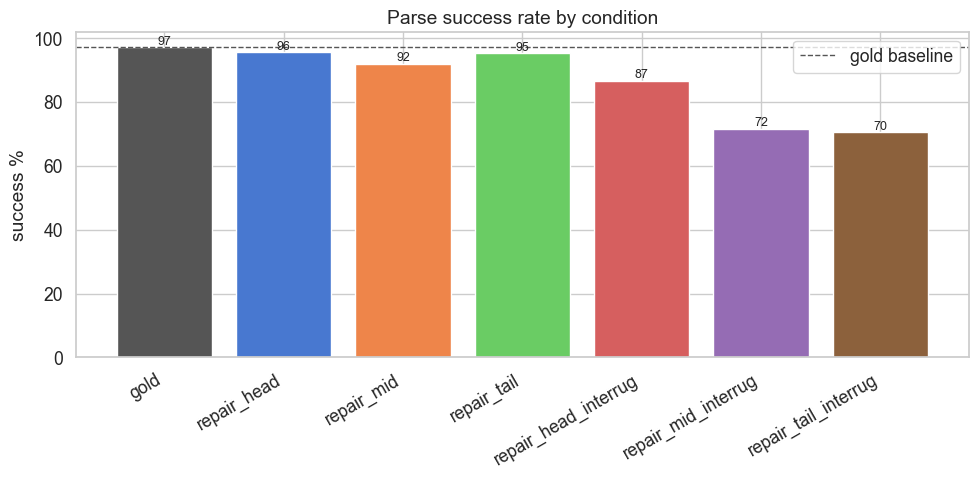

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#555555"] + sns.color_palette("muted", 6)
ax.bar(summary.index, summary["success_%"], color=colors)
ax.axhline(summary.loc["gold", "success_%"], ls="--", c="#555555", lw=1, label="gold baseline")
ax.set_ylabel("success %"); ax.set_title("Parse success rate by condition")
ax.set_xticklabels(summary.index, rotation=30, ha="right"); ax.legend()
for i, v in enumerate(summary["success_%"]):
    ax.text(i, v + 1, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_success_rate.png", dpi=150); plt.show()

## 3. F1 distribution (success-only) by condition

<positron-console-cell-5>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


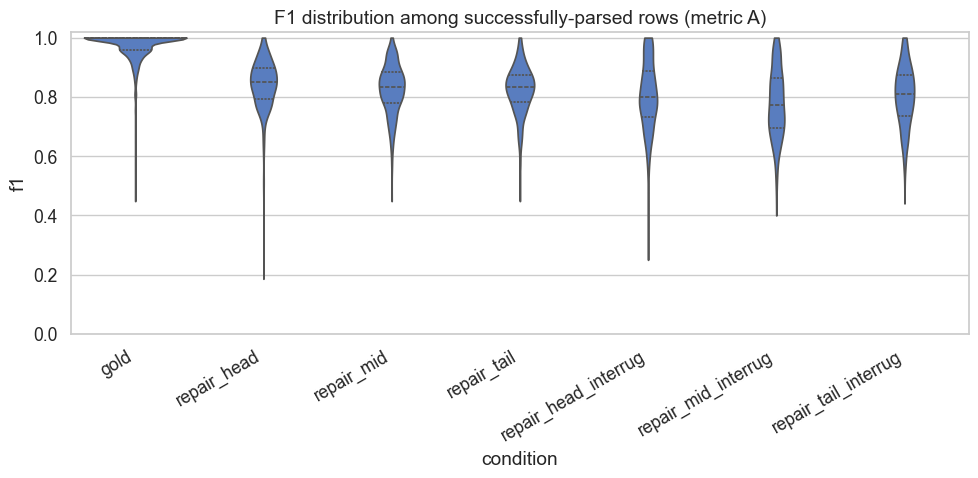

In [5]:
succ = df[df["status"] == "success"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=succ, x="condition", y="f1", order=CONDITION_ORDER, cut=0, inner="quartile", ax=ax)
ax.set_title("F1 distribution among successfully-parsed rows (metric A)")
ax.set_xticklabels(CONDITION_ORDER, rotation=30, ha="right"); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_f1_violin.png", dpi=150); plt.show()

## 4. Penalized F1 (B) — headline degradation metric
Failures count as 0. This is the number to report for "how much does forced self-repair parsing hurt".

<positron-console-cell-6>:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


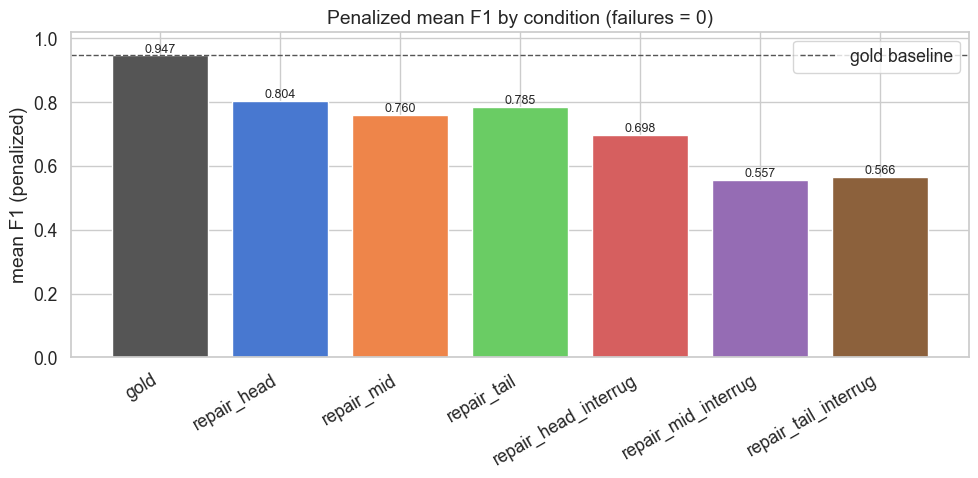

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(summary.index, summary["F1_B_penalized_mean"], color=colors)
ax.axhline(summary.loc["gold", "F1_B_penalized_mean"], ls="--", c="#555555", lw=1, label="gold baseline")
ax.set_ylabel("mean F1 (penalized)"); ax.set_ylim(0, 1.02)
ax.set_title("Penalized mean F1 by condition (failures = 0)")
ax.set_xticklabels(summary.index, rotation=30, ha="right"); ax.legend()
for i, v in enumerate(summary["F1_B_penalized_mean"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_f1_penalized.png", dpi=150); plt.show()

## 5. Failure breakdown (stacked) by condition

<positron-console-cell-7>:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


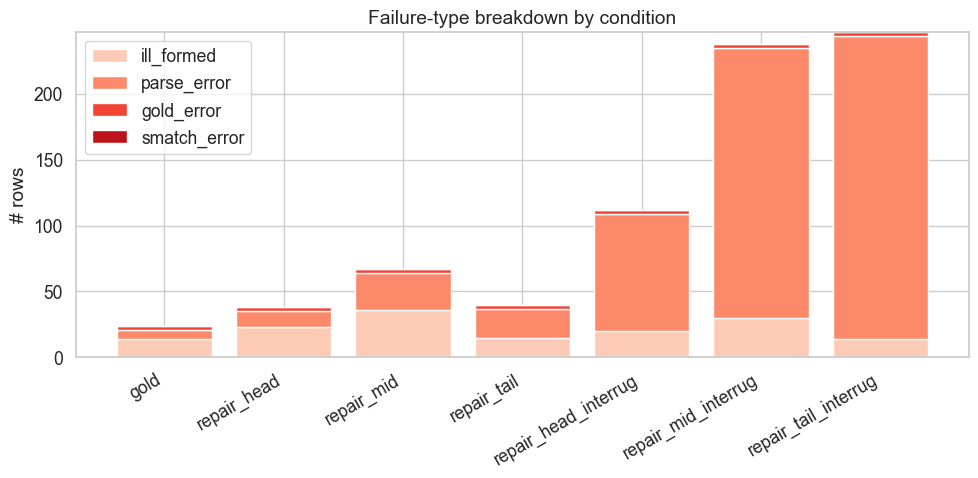

In [7]:
fail_cols = [s for s in STATUS_ORDER if s != "success"]
fails = summary[fail_cols]
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(summary))
pal = sns.color_palette("Reds", len(fail_cols))
for col, c in zip(fail_cols, pal):
    ax.bar(summary.index, fails[col], bottom=bottom, label=col, color=c)
    bottom += fails[col].values
ax.set_ylabel("# rows"); ax.set_title("Failure-type breakdown by condition")
ax.set_xticklabels(summary.index, rotation=30, ha="right"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_failure_breakdown.png", dpi=150); plt.show()

**What the bars say.** Total height = failure rate (so `tail_interrug` fails *most often*); colours = why.

**On the `parse_error` label.** `parse_error` does **not** mean the output was unparseable. Inspecting the 593 rows in this bucket, ~92% (543) are *valid* graphs that contain a **directed cycle** and therefore cannot be linearised to the DAG format smatch++ requires. Thus, they never reach the scorer and are counted as failures. 491 of these fall in the three interregnum conditions (~20% of all interregnum rows; e.g. 224 / 247 of `tail_interrug` failures, 192 / 238 of `mid_interrug`). The cycle is induced by the model **reifying the interregnum marker ("I mean") into a content node** whose back-reference closes a loop — the exact behaviour the next training round targets.  Practically: the tall interregnum bars are driven mainly by this one mechanism, not by many distinct error types.

## 6. Position × interregnum interaction
Does reparandum position (head/mid/tail) and the presence of "I mean" interact? Uses penalized F1.

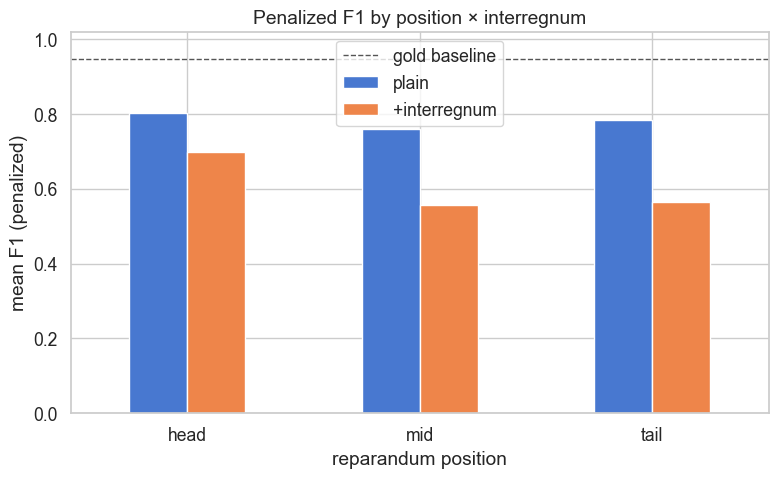

,plain,+interregnum
position,,
head,0.803977,0.697455
mid,0.760298,0.557032
tail,0.785246,0.565669


In [8]:
rep = df[df["position"].isin(POSITION_ORDER)].copy()
piv = rep.groupby(["position", "has_interrug"], observed=True)["f1_pen"].mean().unstack()
piv = piv.reindex(POSITION_ORDER)
piv.columns = ["plain" if c is False else "+interregnum" for c in piv.columns]
ax = piv.plot(kind="bar", figsize=(8, 5), rot=0)
ax.axhline(summary.loc["gold", "F1_B_penalized_mean"], ls="--", c="#555555", lw=1, label="gold baseline")
ax.set_ylabel("mean F1 (penalized)"); ax.set_xlabel("reparandum position")
ax.set_title("Penalized F1 by position × interregnum"); ax.set_ylim(0, 1.02); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "fig_position_interreg.png", dpi=150); plt.show()
piv

## Notes for
* Report **both** F1 metrics; the gap between A and B quantifies how much of the damage is *ill-formed output* vs *wrong-but-valid* structure.
* `gold` success% < 100 is the base parser's own error floor; degradation should be read relative to it, not to 1.0.
* Interregnum ("I mean") effect is the difference between the two bars at each position in §6.